In [1]:
import numpy as np
from matplotlib import pyplot as plt

import utils_data
import utils_detuning

# Simulating a radio frequency cavity

To produce synthetic cavity data, we simulate well-known differential equations of a radio frequency cavity.

### Differential equations of a radio frequency cavity

In the context of cavity detuning, nonlinear cavity dynamics can be expressed using two differential equations: 1) one to describe a radio frequency field oscillating inside the cavity, and 2) the other to model mechanical oscillatory modes of the cavity, i.e.

\begin{equation}
    \begin{split}
        \frac{d}{dt}
        \begin{bmatrix}
            V_{T, I}(t) \\
            V_{T, Q}(t)
        \end{bmatrix}
        =
        \begin{bmatrix}
            -\omega_{1/2} & -\Delta\omega(t) \\
            \Delta\omega(t) & -\omega_{1/2}
        \end{bmatrix}
        \begin{bmatrix}
            V_{T, I}(t) \\
            V_{T, Q}(t)
        \end{bmatrix}
        +
        \begin{bmatrix}
            \omega_{1/2} & 0 \\
            0 & \omega_{1/2}
        \end{bmatrix}
        \begin{bmatrix}
            V_{F, I}(t) \\
            V_{F, Q}(t)
        \end{bmatrix},
    \end{split}
\end{equation}

\begin{equation}
    \begin{split}
        \frac{d}{dt}
        \begin{bmatrix}
            \Delta\omega_n(t) \\
            \Delta\dot{\omega}_n(t)
        \end{bmatrix}
        =
        \begin{bmatrix}
            0 & 1 \\
            -\omega_n^2 & -\frac{\omega_n}{Q_n}
        \end{bmatrix}
        \begin{bmatrix}
            \Delta\omega_n(t) \\
            \Delta\dot{\omega}_n(t)
        \end{bmatrix}
        +
        \begin{bmatrix}
            0 \\
            -k_n\omega_n^2
        \end{bmatrix}
        (V_{T,I}^2(t) + V_{T,Q}^2(t)),
        \\
        n=1,...,N,
        \\
        \Delta\omega(t) = \sum_{n=1}^N \Delta\omega_n(t),
    \end{split}
\end{equation}

where $V_F$ and $V_T$ are a forward and transmitted cavity field, and where indices $I$ and $Q$ denote the in-phase and quadrature components of the cavity field signals, respectively. $N$ is the number of mechanical cavity modes. A time-varying cavity detuning $\Delta\omega(t)$ is opposed to a constant half-bandwidth of a cavity $\omega_{1/2}$. It is also assumed that the frequency $\omega_n$, quality $Q_n$ and the coupling factor $k_n$ of the $n$-th mechanical cavity mode are constant.

### Low-level radio frequency control

We add a simple proportional controller with a gain $K_{rf}=100$, which not only helps to stabilize the cavity field, but effectively extends the bandwidth of the cavity. Otherwise, high-frequency mechanical perturbations become damped by the low-pass nature of the high-$Q$ narrow-bandwidth cavity.

### Implementing a cavity simulator

To simulate the detuning of a cavity we implement a cavity simulator class that is instantiated below.

In [2]:
# --! instatiate a cavity simulator ------------------------------------------------------!

config = {
    'q_rf'       : 4e7,        # loaded quality factor
    'f_rf'       : 1.3e9,      # cavity frequency in hertz
    'v_rf'       : [10., 0.],  # generator voltage
    'pctr_on_rf' : True,       # prortional controller is on
    'K_rf'       : 100.        # proportional controller gain
}

sim = utils_detuning.detuning_sim(config)

inf >> half-bandwidth of this radio frequency cavity is 16.25 Herz
inf >> cavity filling time is 0.06 seconds


# Generating cavity data via simulations

For our experiments, we generate both stationary and transitional data. The former is used to train the global Koopman operator, whereas the latter --- to train the local one.

### Stationary data for training

The stationary data includes a 10Hz, 24Hz, as well as the sum of the two oscillations. The simulated stationary data is saved to a folder that is later used to train the global Koopman operator.

inf >> number of mechanical modes specified: 1
inf >> number of mechanical modes specified: 1
inf >> number of mechanical modes specified: 2


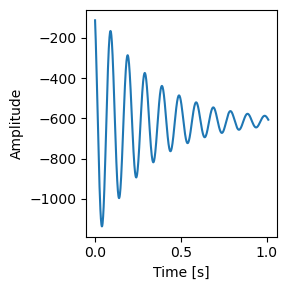

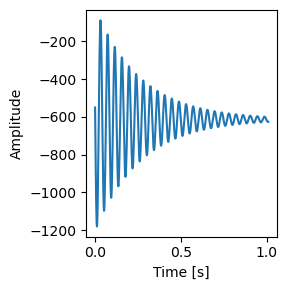

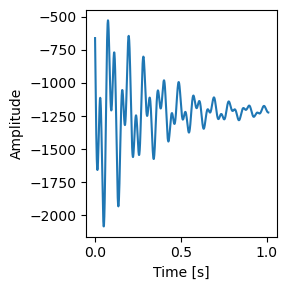

inf >> training files saved


In [3]:
# --! simulate with parameters -----------------------------------------------!

dt = 0.001

# --! define a list of simulation parameters
sim_param = [
    {
        'f_m'    : np.array([10.]),
        'q_m'    : np.array([10.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 17,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([24.]),
        'q_m'    : np.array([20.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 17,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([10., 24.]),
        'q_m'    : np.array([10., 20.]),
        't_m'    : np.array([[-1., -1.], [-1., -1.]]),
        't_rf_n' : 17,
        'dt'     : dt,
    }
]

stadets_sca = sim(sim_param)

# --! display resulting detuning
for det in stadets_sca:
    sim.disp(det, timestep=dt)

# --! save timeseries
savedata_on      = True
savedata_dir     = 'data/train_sim_g'
savedata_nsample = 200
if savedata_on:
    utils_data.save_traindata(stadets_sca, savedata_dir, savedata_nsample)
else:
    print('wrn >> global training file saving is switched off')

### Transient data for training

The transient data includes a transition from 10Hz to 24Hz and back to 10Hz.

inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 2


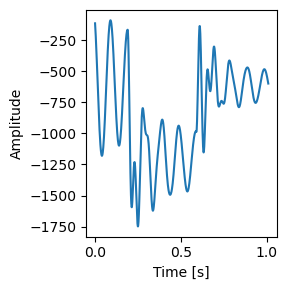

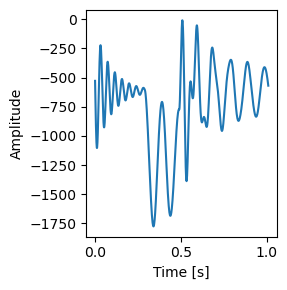

inf >> training files saved


In [4]:
# --! simulate with parameters -----------------------------------------------!

dt = 0.001

sim_param = [
    {
        'f_m'    : np.array([10., 24.]),
        'q_m'    : np.array([20., 5.]),
        't_m'    : np.array([[-1., -1.], [0.2, 0.6]]),
        't_rf_n' : 17,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([10., 24.]),
        'q_m'    : np.array([20., 7.]),
        't_m'    : np.array([[0.3, -1.], [-1., 0.5]]),
        't_rf_n' : 17,
        'dt'     : dt,
    }
]

transdets_sca = sim(sim_param)

# --! display resulting detuning
for det in transdets_sca:
    sim.disp(det, timestep=dt)

# --! save timeseries
savedata_on      = True
savedata_dir     = 'data/train_sim_l'
savedata_nsample = 200
if savedata_on:
    utils_data.save_traindata(transdets_sca, savedata_dir, savedata_nsample)
else:
    print('wrn >> local training file saving is switched off')

### Stationary and transient data to train model variance

In [5]:
# --! save timeseries
savedata_on      = True
savedata_dir     = 'data/train_sim_mix'
savedata_nsample = 200
mixdets_sca      = stadets_sca + transdets_sca
if savedata_on:
    utils_data.save_traindata(mixdets_sca, savedata_dir, savedata_nsample)
else:
    print('wrn >> local training file saving is switched off')

inf >> training files saved


### Transient data for model evaluation

inf >> number of mechanical modes specified: 2


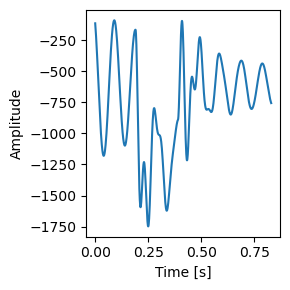

inf >> detuning length is 830 samples
inf >> evaluation file saved


In [6]:
dt = 0.001

sim_param = [
    {
        'f_m'    : np.array([10., 24.]),
        'q_m'    : np.array([20., 5.]),
        't_m'    : np.array([[-1., -1.], [0.2, 0.4]]),
        't_rf_n' : 14,
        'dt'     : dt,
    }
]

dets_sca = sim(sim_param)

# --! display resulting detuning
for det in dets_sca:
    sim.disp(det, timestep=dt)

print(f'inf >> detuning length is {len(dets_sca[0][:, 0])} samples')

# --! save timeseries
savedata_on        = True
savedata_dir       = 'data/eval_sim'
savedata_nsample   = 200
if savedata_on:
    utils_data.save_testdata(dets_sca, savedata_dir, savedata_nsample)
else:
    print('wrn >> evaluation file saving is switched off')